In [2]:
# 1. Cargar datos del CSV
import pandas as pd

df = pd.read_csv('ventas_tienda.csv')

In [3]:
# 2. Calcular ventas totales por mes
df['fecha'] = pd.to_datetime(df['fecha'])

df['mes'] = df['fecha'].dt.to_period('M')

ventas_por_mes = df.groupby('mes').apply(lambda d: (d['cantidad'] * d['precio']).sum())

ventas_por_mes = ventas_por_mes.sort_index()

print("Ventas por mes:")

print(ventas_por_mes)

Ventas por mes:
mes
2025-01     440.0
2025-02     730.0
2025-03    1056.0
2025-04    1000.0
2025-05     840.0
Freq: M, dtype: float64


C:\Users\david\AppData\Local\Temp\ipykernel_22972\3811952684.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ventas_por_mes = df.groupby('mes').apply(lambda d: (d['cantidad'] * d['precio']).sum())


In [4]:
# 2. Calcular ventas totales por mes
df['mes'] = df['fecha'].dt.to_period('M')

ventas_por_mes = df.groupby('mes').apply(lambda d: (d['cantidad'] * d['precio']).sum())

ventas_por_mes = ventas_por_mes.sort_index()

print("Ventas por mes:")

print(ventas_por_mes)

Ventas por mes:
mes
2025-01     440.0
2025-02     730.0
2025-03    1056.0
2025-04    1000.0
2025-05     840.0
Freq: M, dtype: float64


C:\Users\david\AppData\Local\Temp\ipykernel_22972\2290758442.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ventas_por_mes = df.groupby('mes').apply(lambda d: (d['cantidad'] * d['precio']).sum())


In [5]:
# 3. Determinar producto más vendido y con mayor ingresos
df['ingreso'] = df['cantidad'] * df['precio']

ventas_prod = df.groupby('producto').agg({

    'cantidad': 'sum',

    'ingreso': 'sum'

})

mas_vendido = ventas_prod['cantidad'].idxmax()

mayor_ingreso = ventas_prod['ingreso'].idxmax()

print(f"Producto más vendido en unidades: {mas_vendido} (total {ventas_prod.loc[mas_vendido, 'cantidad']})")

print(f"Producto con mayores ingresos: {mayor_ingreso} (total {ventas_prod.loc[mayor_ingreso, 'ingreso']:.2f} €)")


Producto más vendido en unidades: Calcetines (total 37)
Producto con mayores ingresos: Pantalón (total 735.00 €)


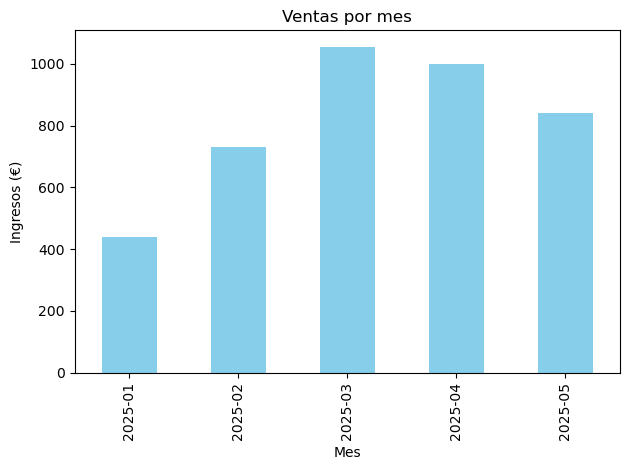

In [6]:
# 4. Graficar ventas por mes
import matplotlib.pyplot as plt

ventas_por_mes.plot(kind='bar', color='skyblue')
plt.title('Ventas por mes')
plt.xlabel('Mes')
plt.ylabel('Ingresos (€)')
plt.tight_layout()
plt.show()

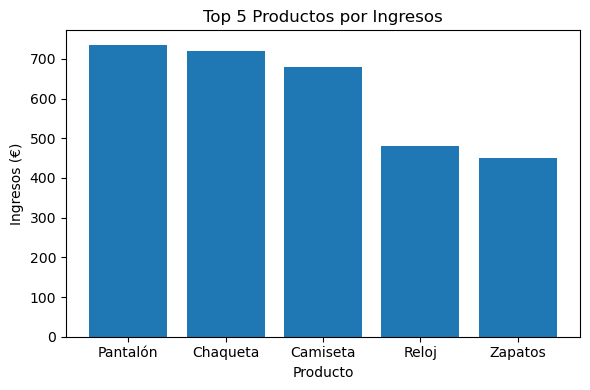

In [7]:
# 5. Graficar top 5 productos por ingresos
best_products = ventas_prod.nlargest(5, 'ingreso')
plt.figure(figsize=(6,4))

plt.bar(best_products.index, best_products['ingreso'])

plt.title("Top 5 Productos por Ingresos")

plt.ylabel("Ingresos (€)")

plt.xlabel("Producto")

plt.tight_layout()

plt.savefig("top5_productos.png")

plt.show() 